In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [17]:
import cv2
import numpy as np
import requests

image_url = 'https://raw.githubusercontent.com/RafRizu/Histogram-Minyak-Jelantah/37f281cc7d91e0f5bc3aceff38a27496fb8c368c/minyak1.jpg'

def proses_minyak_dari_url(url):

    response = requests.get(url)
    if response.status_code != 200:
        print(f"Gagal mengunduh gambar! Status code: {response.status_code}")
        return None, None, None, None, None

    # Convert data biner internet ke numpy array, lalu decode ke format OpenCV BGR
    arr = np.asarray(bytearray(response.content), dtype=np.uint8)
    img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)

    if img_bgr is None:
        print("Gagal men-decode gambar!")
        return None, None, None, None, None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    batas_bawah_kuning = np.array([10, 40, 40])
    batas_atas_kuning = np.array([40, 255, 255])

    mask_kuning = cv2.inRange(img_hsv, batas_bawah_kuning, batas_atas_kuning)
    piksel_terseleksi = img_gray[mask_kuning > 0]

    if len(piksel_terseleksi) == 0:
        print("Peringatan: Tidak ditemukan warna kekuningan pada sampel gambar!")
        rata_intensitas = 0
    else:
        rata_intensitas = np.mean(piksel_terseleksi)

    if rata_intensitas > 140:
        status = "LAYAK"
        warna_status = "green"
    elif 90 <= rata_intensitas <= 140:
        status = "WASPADA"
        warna_status = "orange"
    else:
        status = "BUANG (JELANTAH)"
        warna_status = "red"

    print(f"Proses Berhasil dengan Seleksi Warna!")
    print(f"Status Minyak: {status} (Rata-rata Intensitas Minyak: {rata_intensitas:.2f})")

    return img_rgb, mask_kuning, rata_intensitas, status, warna_status

# Jalankan fungsi baru
img_rgb, mask_kuning, rata_intensitas, status, warna_status = proses_minyak_dari_url(image_url)

Proses Berhasil dengan Seleksi Warna!
Status Minyak: LAYAK (Rata-rata Intensitas Minyak: 160.79)


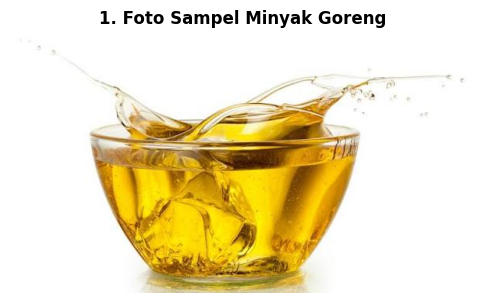

In [18]:
if img_rgb is not None:
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title("1. Foto Sampel Minyak Goreng", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

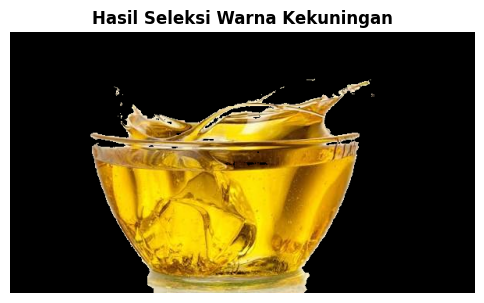

In [19]:
if mask_kuning is not None and img_rgb is not None:
    # Aplikasikan mask_kuning ke gambar RGB asli
    res_kuning = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_kuning)

    plt.figure(figsize=(6, 6))
    # Tampilkan hasil seleksi warna kuning
    plt.imshow(res_kuning)
    plt.title("Hasil Seleksi Warna Kekuningan", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

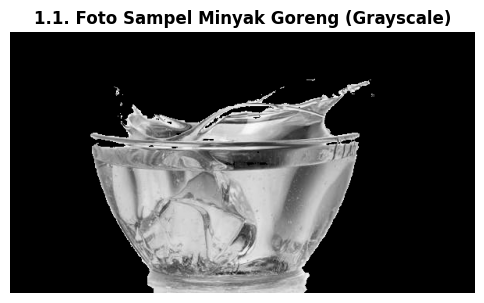

In [20]:
if img_rgb is not None:
    img_gray = cv2.cvtColor(res_kuning, cv2.COLOR_RGB2GRAY)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_gray, cmap='gray')
    plt.title("1.1. Foto Sampel Minyak Goreng (Grayscale)", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

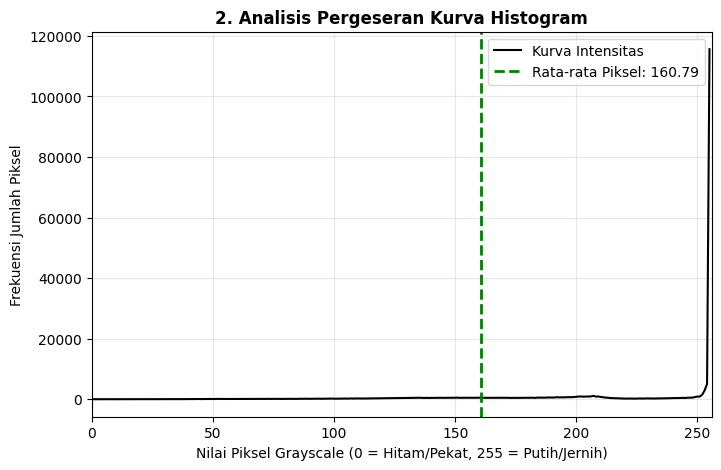

In [21]:
if img_rgb is not None:

    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    plt.figure(figsize=(8, 5))
    hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

    plt.plot(hist, color='black', label='Kurva Intensitas')
    plt.axvline(rata_intensitas, color=warna_status, linestyle='--', linewidth=2,
                label=f'Rata-rata Piksel: {rata_intensitas:.2f}')

    plt.title("2. Analisis Pergeseran Kurva Histogram", fontsize=12, fontweight='bold')
    plt.xlabel("Nilai Piksel Grayscale (0 = Hitam/Pekat, 255 = Putih/Jernih)")
    plt.ylabel("Frekuensi Jumlah Piksel")
    plt.xlim([0, 256])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Error: img_rgb is not defined. Cannot generate histogram.")

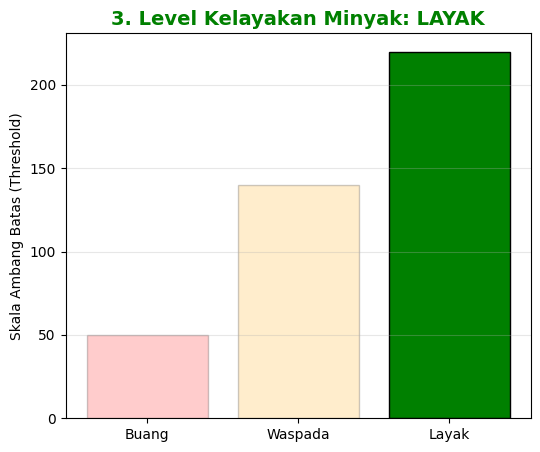

In [22]:
if status is not None:
    plt.figure(figsize=(6, 5))
    kategori = ['Buang', 'Waspada', 'Layak']
    nilai_representatif = [50, 140, 220]
    warna_bar = ['red', 'orange', 'green']

    # Buat bar dasar transparan
    bars = plt.bar(kategori, nilai_representatif, color=warna_bar, alpha=0.2, edgecolor='black')

    # Beri warna penuh (solid) hanya pada status yang aktif saat ini
    if status == "LAYAK":
        bars[2].set_alpha(1.0)
        bars[2].set_edgecolor('black')
    elif status == "WASPADA":
        bars[1].set_alpha(1.0)
        bars[1].set_edgecolor('black')
    else:
        bars[0].set_alpha(1.0)
        bars[0].set_edgecolor('black')

    plt.title(f"3. Level Kelayakan Minyak: {status}", color=warna_status, fontsize=14, fontweight='bold')
    plt.ylabel("Skala Ambang Batas (Threshold)")
    plt.grid(axis='y', alpha=0.3)
    plt.show()